# AI-POWERED MANUFACTURING QUALITY INTELLIGENCE SYSTEM

## Exploratory Data Analysis

This notebook performs exploratory data analysis on the manufacturing dataset to understand the dataset structure, variable distributions, target variables, relationships between manufacturing parameters, and potential data-quality issues.

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

### Load the dataset

In [2]:
df = pd.read_csv("manufacturing_quality_intelligence.csv")

df.head()

,reading_id,machine_id,production_line,machine_type,timestamp,machine_age_years,hours_since_maintenance,maintenance_event,load_factor,temperature_c,vibration_mm_s,pressure_psi,current_a,rpm,cycle_time_sec,tool_wear_pct,machine_health_index,quality_score,quality_pass,is_anomaly,machine_failure,maintenance_due
0,R001_001,MC-001,Line-H,Lathe,01-01-2026 00:00,4.35,0,1,0.683,77.01,4.842,108.99,83.92,2149.9,15.488,6.06,0.928,91.95,1,0,0,0
1,R001_002,MC-001,Line-H,Lathe,01-01-2026 08:00,4.35,1,0,0.692,75.57,5.902,103.96,71.99,2143.9,14.713,10.47,0.921,89.80,1,0,0,0
2,R001_003,MC-001,Line-H,Lathe,01-01-2026 16:00,4.35,2,0,0.599,75.67,5.165,105.57,62.79,2054.3,15.571,11.17,0.917,94.92,1,0,0,0
3,R001_004,MC-001,Line-H,Lathe,02-01-2026 00:00,4.35,3,0,0.917,77.28,5.005,110.23,79.05,2424.1,13.504,5.41,0.865,82.88,1,0,1,1
4,R001_005,MC-001,Line-H,Lathe,02-01-2026 08:00,4.35,4,0,0.583,72.43,5.109,107.36,73.61,2019.9,16.135,19.24,0.865,91.70,1,0,0,0


In [3]:
df.shape

(6000, 22)

### Dataset Overview

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 6000
Columns: 22


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   reading_id               6000 non-null   object 
 1   machine_id               6000 non-null   object 
 2   production_line          6000 non-null   object 
 3   machine_type             6000 non-null   object 
 4   timestamp                6000 non-null   object 
 5   machine_age_years        6000 non-null   float64
 6   hours_since_maintenance  6000 non-null   int64  
 7   maintenance_event        6000 non-null   int64  
 8   load_factor              6000 non-null   float64
 9   temperature_c            6000 non-null   float64
 10  vibration_mm_s           6000 non-null   float64
 11  pressure_psi             6000 non-null   float64
 12  current_a                6000 non-null   float64
 13  rpm                      6000 non-null   float64
 14  cycle_time_sec          

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
machine_age_years,6000.0,8.113333,3.958353,1.030,4.63500,8.3450,11.15500,14.990
hours_since_maintenance,6000.0,10.294167,6.872470,0.000,4.00000,10.0000,16.00000,29.000
maintenance_event,6000.0,0.052000,0.222046,0.000,0.00000,0.0000,0.00000,1.000
load_factor,6000.0,0.680559,0.130811,0.300,0.59100,0.6820,0.77000,1.000
temperature_c,6000.0,78.456688,3.743159,66.510,75.75000,78.3800,81.05000,93.310
vibration_mm_s,6000.0,6.034574,1.230368,2.335,5.14300,5.9960,6.88725,10.745
pressure_psi,6000.0,109.741400,9.886322,79.390,105.09750,111.1700,116.73000,132.030
current_a,6000.0,79.295608,7.335021,53.430,73.96000,79.5650,84.65000,102.350
rpm,6000.0,2097.476183,199.751069,1471.700,1964.30000,2098.7000,2232.20000,2708.900
cycle_time_sec,6000.0,16.289485,1.518314,12.608,15.25975,16.0915,17.08600,24.401


### Column names

In [7]:
df.columns

Index(['reading_id', 'machine_id', 'production_line', 'machine_type',
       'timestamp', 'machine_age_years', 'hours_since_maintenance',
       'maintenance_event', 'load_factor', 'temperature_c', 'vibration_mm_s',
       'pressure_psi', 'current_a', 'rpm', 'cycle_time_sec', 'tool_wear_pct',
       'machine_health_index', 'quality_score', 'quality_pass', 'is_anomaly',
       'machine_failure', 'maintenance_due'],
      dtype='object')

In [8]:
df.head()

,reading_id,machine_id,production_line,machine_type,timestamp,machine_age_years,hours_since_maintenance,maintenance_event,load_factor,temperature_c,vibration_mm_s,pressure_psi,current_a,rpm,cycle_time_sec,tool_wear_pct,machine_health_index,quality_score,quality_pass,is_anomaly,machine_failure,maintenance_due
0,R001_001,MC-001,Line-H,Lathe,01-01-2026 00:00,4.35,0,1,0.683,77.01,4.842,108.99,83.92,2149.9,15.488,6.06,0.928,91.95,1,0,0,0
1,R001_002,MC-001,Line-H,Lathe,01-01-2026 08:00,4.35,1,0,0.692,75.57,5.902,103.96,71.99,2143.9,14.713,10.47,0.921,89.80,1,0,0,0
2,R001_003,MC-001,Line-H,Lathe,01-01-2026 16:00,4.35,2,0,0.599,75.67,5.165,105.57,62.79,2054.3,15.571,11.17,0.917,94.92,1,0,0,0
3,R001_004,MC-001,Line-H,Lathe,02-01-2026 00:00,4.35,3,0,0.917,77.28,5.005,110.23,79.05,2424.1,13.504,5.41,0.865,82.88,1,0,1,1
4,R001_005,MC-001,Line-H,Lathe,02-01-2026 08:00,4.35,4,0,0.583,72.43,5.109,107.36,73.61,2019.9,16.135,19.24,0.865,91.70,1,0,0,0


### Missing values

In [9]:
df.isnull().sum()

reading_id                 0
machine_id                 0
production_line            0
machine_type               0
timestamp                  0
machine_age_years          0
hours_since_maintenance    0
maintenance_event          0
load_factor                0
temperature_c              0
vibration_mm_s             0
pressure_psi               0
current_a                  0
rpm                        0
cycle_time_sec             0
tool_wear_pct              0
machine_health_index       0
quality_score              0
quality_pass               0
is_anomaly                 0
machine_failure            0
maintenance_due            0
dtype: int64

In [10]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


### Duplicate records

In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### Numerical and categorical variables

In [12]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['machine_age_years', 'hours_since_maintenance', 'maintenance_event', 'load_factor', 'temperature_c', 'vibration_mm_s', 'pressure_psi', 'current_a', 'rpm', 'cycle_time_sec', 'tool_wear_pct', 'machine_health_index', 'quality_score', 'quality_pass', 'is_anomaly', 'machine_failure', 'maintenance_due']

Categorical columns:
['reading_id', 'machine_id', 'production_line', 'machine_type', 'timestamp']


### Target-variable analysis

In [13]:
# MACHINE FAILURE

print("Machine Failure:")
print(df["machine_failure"].value_counts())

Machine Failure:
machine_failure
0    5480
1     520
Name: count, dtype: int64


In [14]:
# ANOMALY

print("\nAnomaly:")
print(df["is_anomaly"].value_counts())


Anomaly:
is_anomaly
0    4695
1    1305
Name: count, dtype: int64


In [15]:
# QUALITY

print("\nQuality:")
print(df["quality_pass"].value_counts())


Quality:
quality_pass
1    5482
0     518
Name: count, dtype: int64


### Target visualization

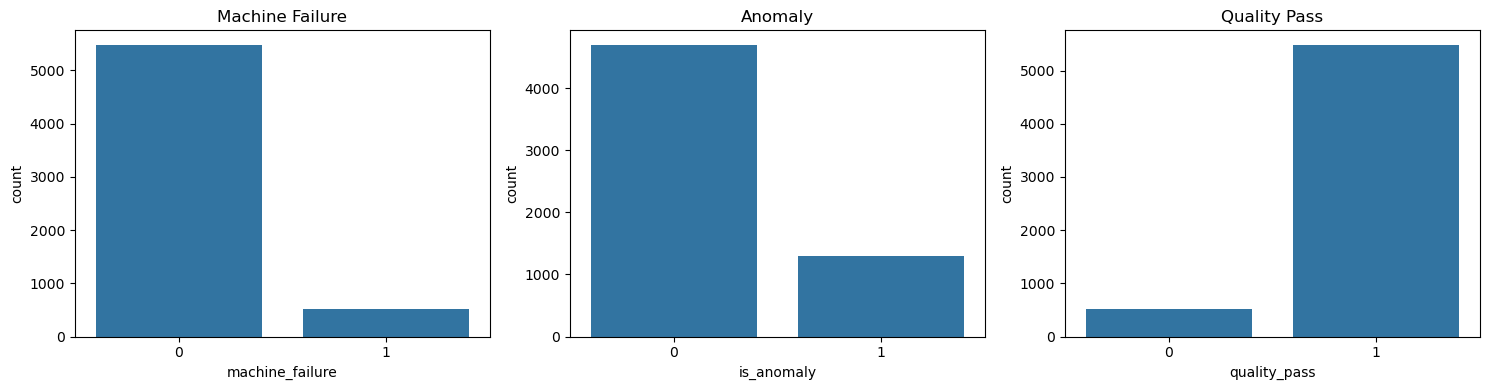

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x="machine_failure", ax=axes[0])
axes[0].set_title("Machine Failure")

sns.countplot(data=df, x="is_anomaly", ax=axes[1])
axes[1].set_title("Anomaly")

sns.countplot(data=df, x="quality_pass", ax=axes[2])
axes[2].set_title("Quality Pass")

plt.tight_layout()
plt.show()

### Numerical distributions

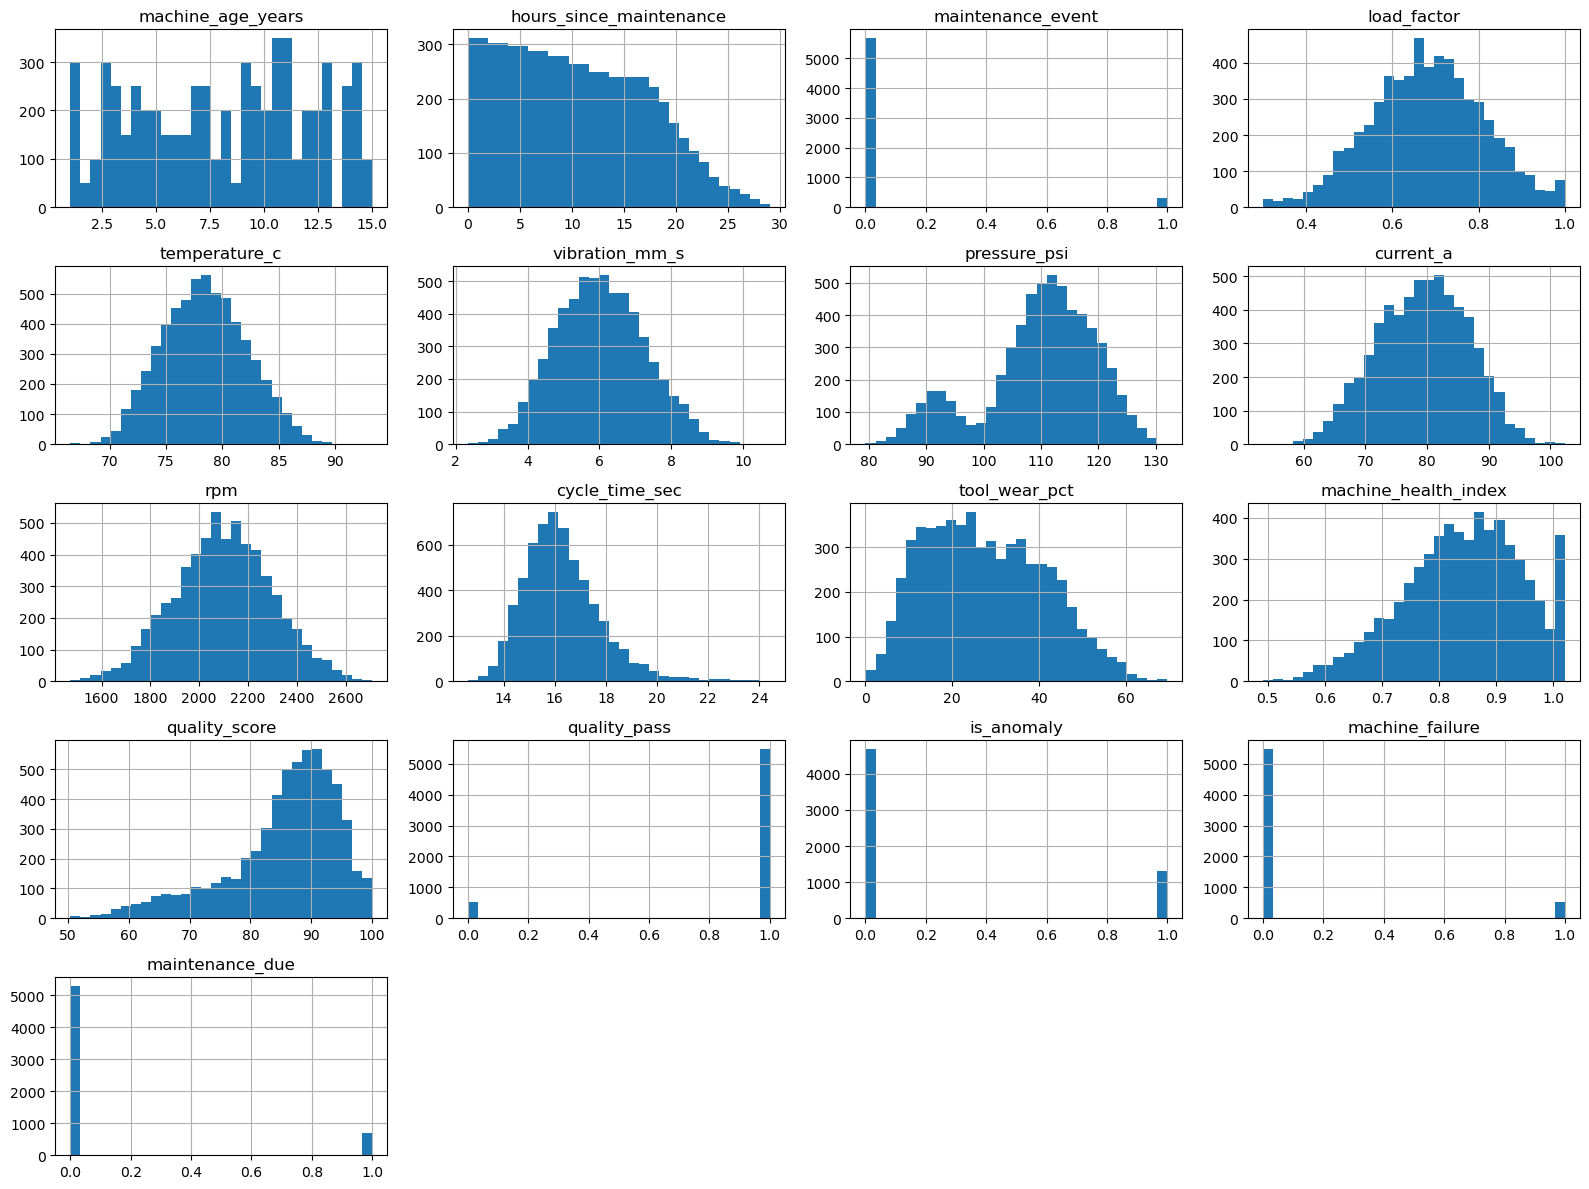

In [35]:
df[numerical_columns].hist(
    figsize=(16, 12),
    bins=30
)

plt.tight_layout()
plt.show()

### Correlation analysis

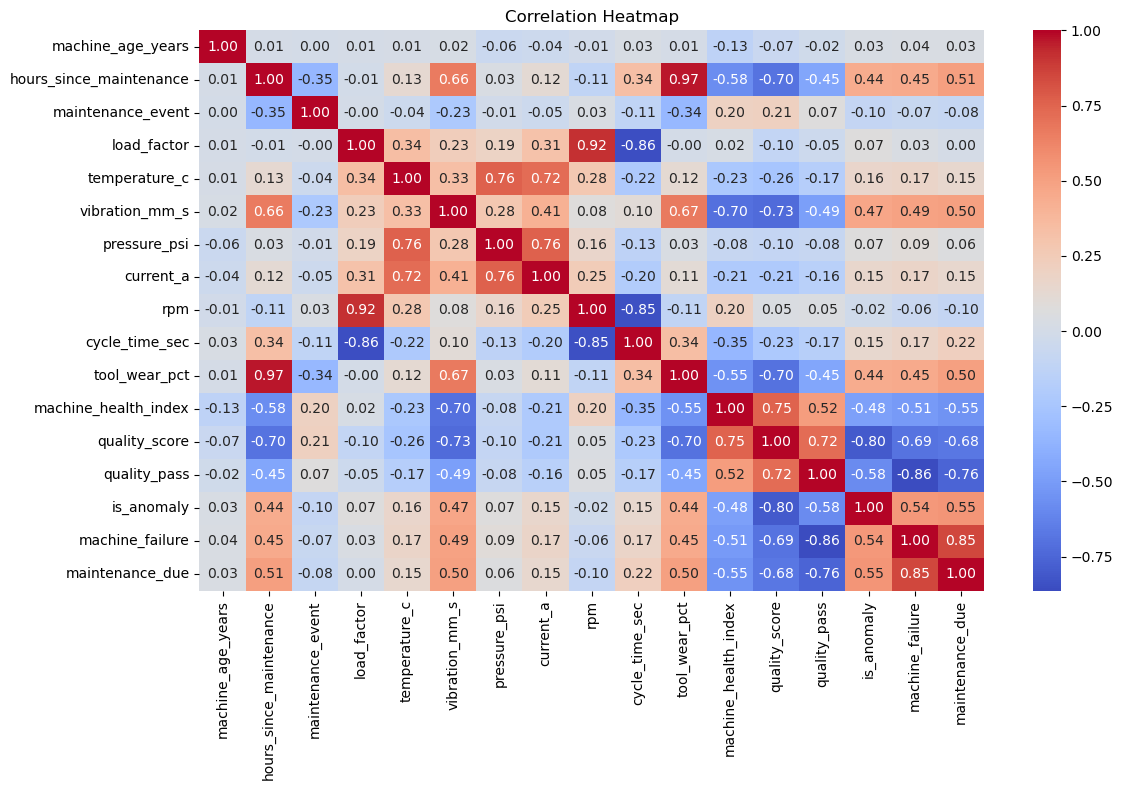

In [36]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numerical_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.show()

### Outlier analysis

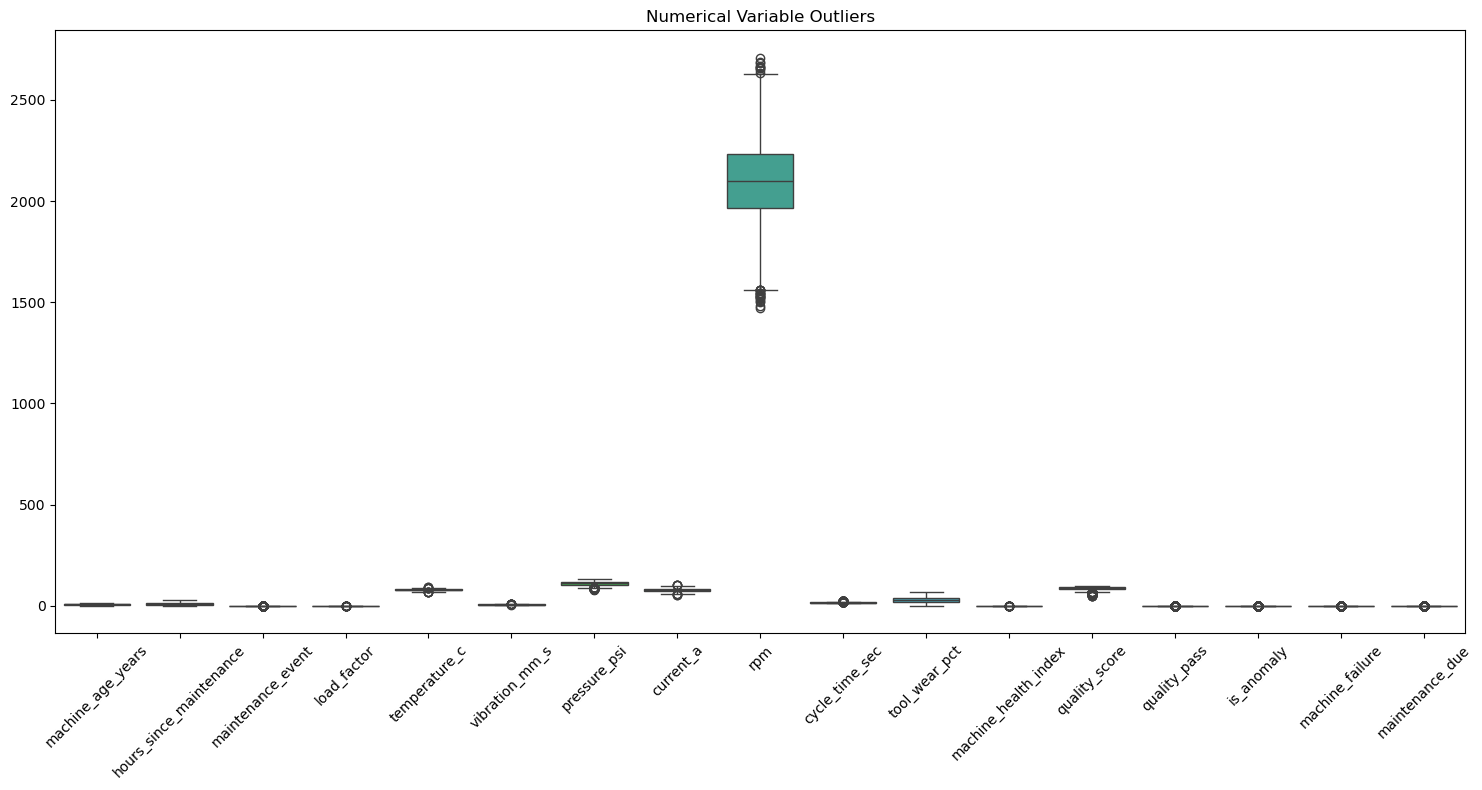

In [19]:
plt.figure(figsize=(15, 8))

sns.boxplot(data=df[numerical_columns])

plt.xticks(rotation=45)
plt.title("Numerical Variable Outliers")
plt.tight_layout()

plt.show()

In [20]:
print(numerical_columns)

['machine_age_years', 'hours_since_maintenance', 'maintenance_event', 'load_factor', 'temperature_c', 'vibration_mm_s', 'pressure_psi', 'current_a', 'rpm', 'cycle_time_sec', 'tool_wear_pct', 'machine_health_index', 'quality_score', 'quality_pass', 'is_anomaly', 'machine_failure', 'maintenance_due']


### Relevant manufacturing relationships

The relationship between important manufacturing parameters and machine failure is examined to identify patterns that may be useful for predictive maintenance.

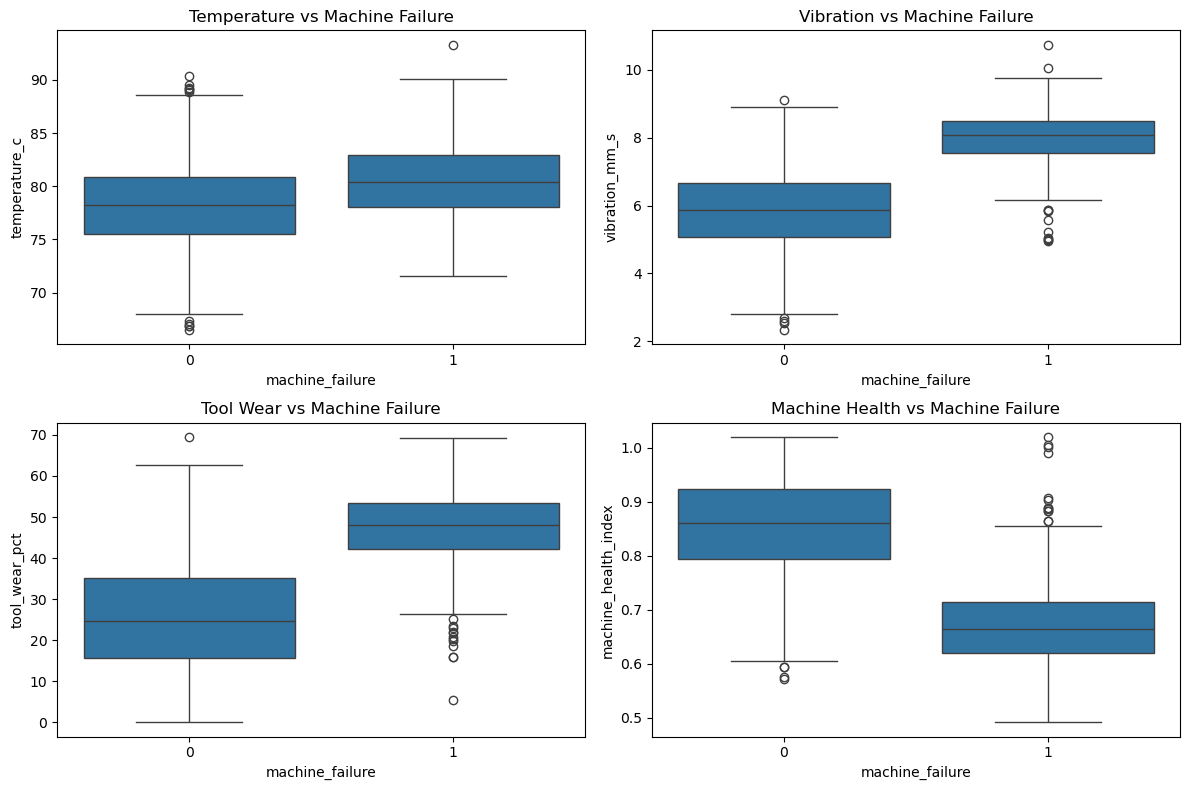

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=df, x="machine_failure", y="temperature_c", ax=axes[0, 0])
axes[0, 0].set_title("Temperature vs Machine Failure")

sns.boxplot(data=df, x="machine_failure", y="vibration_mm_s", ax=axes[0, 1])
axes[0, 1].set_title("Vibration vs Machine Failure")

sns.boxplot(data=df, x="machine_failure", y="tool_wear_pct", ax=axes[1, 0])
axes[1, 0].set_title("Tool Wear vs Machine Failure")

sns.boxplot(data=df, x="machine_failure", y="machine_health_index", ax=axes[1, 1])
axes[1, 1].set_title("Machine Health vs Machine Failure")

plt.tight_layout()

plt.show()

In [25]:
# Temperature: failed machines tend to have higher temperatures than non-failed machines.
# Vibration: this shows a very clear increase for failed machines.
# Tool wear: failed machines have substantially higher tool wear.
# Machine health index: failed machines have noticeably lower health scores.

### Quality relationship plot

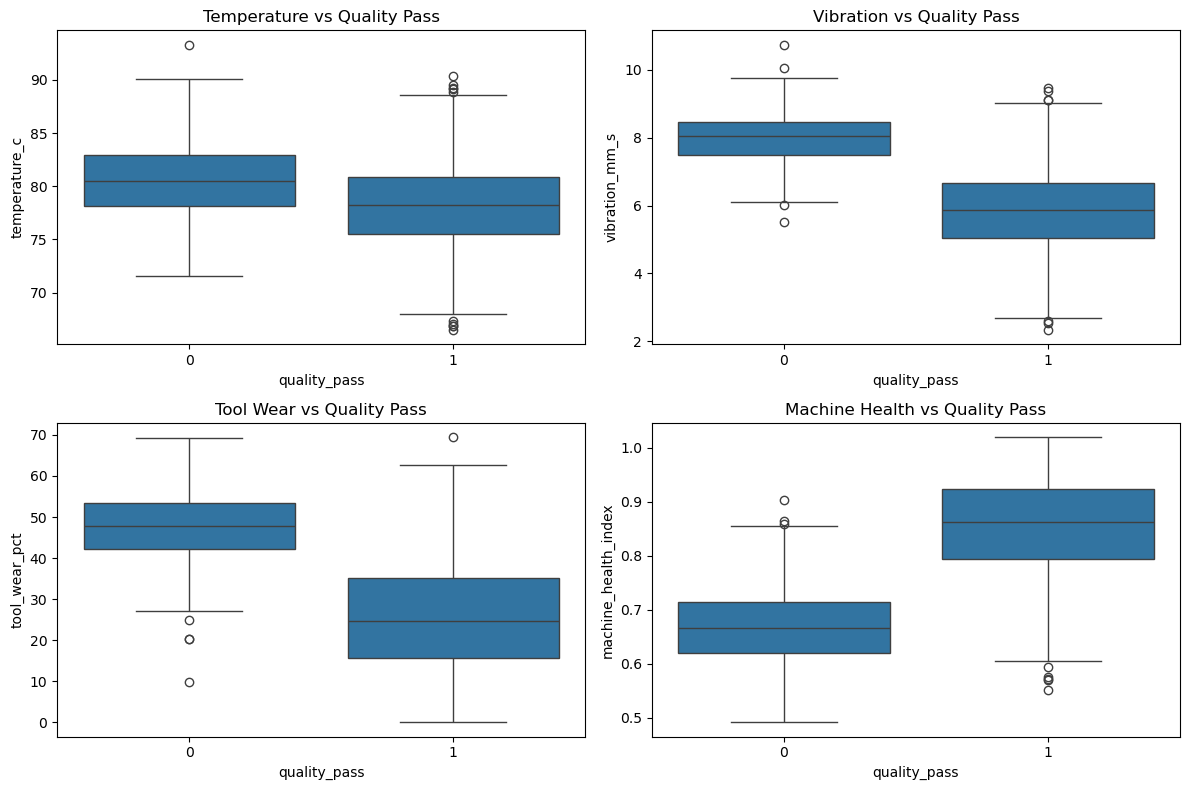

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=df, x="quality_pass", y="temperature_c", ax=axes[0, 0])
axes[0, 0].set_title("Temperature vs Quality Pass")

sns.boxplot(data=df, x="quality_pass", y="vibration_mm_s", ax=axes[0, 1])
axes[0, 1].set_title("Vibration vs Quality Pass")

sns.boxplot(data=df, x="quality_pass", y="tool_wear_pct", ax=axes[1, 0])
axes[1, 0].set_title("Tool Wear vs Quality Pass")

sns.boxplot(data=df, x="quality_pass", y="machine_health_index", ax=axes[1, 1])
axes[1, 1].set_title("Machine Health vs Quality Pass")

plt.tight_layout()

plt.show()

In [26]:
# Temperature: failed quality samples (quality_pass = 0) generally have higher temperatures.
# Vibration: failed quality samples show noticeably higher vibration.
# Tool wear: this is one of the clearest differences — failed-quality samples have substantially higher tool wear.
# Machine health: passed-quality samples have a noticeably higher machine health index.

### EDA Findings

- The dataset contains machine, production, sensor, maintenance, quality, anomaly, and failure-related information.
- The target variables `machine_failure`, `is_anomaly`, and `quality_pass` provide the basis for the three main prediction tasks.
- Failed machines generally show higher temperature, vibration, and tool wear, while their machine health index tends to be lower.
- Quality-failed samples generally show higher temperature, vibration, and tool wear, while quality-passed samples tend to have a higher machine health index.
- These relationships indicate that machine-condition and sensor-related features contain useful information for predictive maintenance and quality prediction.
- The dataset contains both numerical and categorical features, so appropriate preprocessing will be required before model training.
- The EDA also examined data quality, distributions, correlations, and potential outliers to understand the dataset before preprocessing.